# Melbourne Housing Market  

Name : Arjun Ajikumar

Batch : ML - DAF50

Dataset Link : https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot/code

Submission Date : 30-09-2026

## Melbourne Housing Market - Exploratory Data Analysis

- **Domain:** Real Estate 
- **Dataset:** 'melb_data.csv' (Melbourne housing snapshot — 13,580 records, 21 columns)

## Introduction

This document specifies the requirements for an end-to-end data analytics project designed to analyze residential property sales in Melbourne, Australia, and to predict property sale prices. The system will process historical real-estate listing and auction-result records to identify the key structural, locational, and market-timing factors that drive a property's sale price. The goal is to support buyers, sellers, and real-estate analysts with data-driven pricing insight and suburb-level market intelligence.


## Key Objectives

- 	Clean and standardize the raw property dataset by resolving structural missing values in building attributes (*BuildingArea, YearBuilt,                 CouncilArea, Car*) that arise from incomplete listing records.

- 	Identify the strongest predictors of sale price, including location (*Suburb, Regionname, distance to City Block Distance*), property characteristics (*Rooms, Type,      Landsize, BuildingArea*), and sale method (*Method*).

- 	Build a regression model that estimates the expected sale price given a property's attributes.

- 	Build a complete data pipeline using Python only for cleaning, feature engineering, EDA, and modeling.


## Data Sources & Extraction

This project uses the Melbourne Housing Snapshot dataset (melb_data.csv) from Kaggle, containing 13,580 property sale records across 21 attributes, organized into four distinct data groups:

•	**Property Structural Data**: *Rooms, Type, Bedroom2, Bathroom, Car, Landsize, BuildingArea, YearBuilt*.

•	**Location Data**: *Suburb, Address, Postcode, CouncilArea, Regionname, Lattitude, Longtitude, Distance (distance to CBD)*.

•	**Sale Transaction Data**: *Price, Method, SellerG, Date*.

•	**Target Variable**: *Price — the property's recorded sale price (continuous, AUD)*.


## Problem Statement
Melbourne's property market is shaped by location, property type, and sale method. This project
explores the dataset to answer:

1. How do property **prices** vary by **type**, **region**, and **distance from the City Block Distance**?
2. Which **sale methods** are most common, and do they influence price?
3. How does the **age of a property** relate to its price?
4. Are there strong **correlations** between price and physical attributes (rooms, bathrooms, land size, building area)?
5. What seasonal or yearly **trends** exist in the sales data?

## **Data Handling Process**

- **Importing Libraries we need**

 ### **1. Data Loading and Initial Overview (Phase 1)**
        1.0 Data Loading and Initial Overview
 ### **2. Data Pre-processing (Phase 2)**

        2.0 Data Pre-processing

        2.1 Removel of unwanted columns

        2.2 Rename the columns

        2.3 Checking for Duplicate values

        2.4 Checking for missing values

        2.5 Correcting data types

        2.6 Decoding Method and Type into their full forms

        2.7 Creating derived columns

        2.8 Filtering the data

 ### **3. Exploratory Data Analysis (Phase 3)**

        3.1 Univariate Analysis
          => 3.1.1 Statistical summaries to support findings
          => 3.1.2 Frequency of each property Type and sale Method 

        3.2 Bivariate Analysis
          => 3.2.1 Average price by property Type 
          => 3.2.2 Average price by Region
          => 3.2.3 Correlation between Price and Distance from City Block Distance
          => 3.2.4 Bivariate Graph — Grouped Bar Chart: Average Price by Number of Rooms
  
        3.3 Multivariate Analysis
          => 3.3.1 Price Distribution: Region vs. Property Type
          => 3.3.2 Sales Method: Rate Per Square vs. Property Age
          => 3.3.3 Linear Relationships Across Key Numeric Features

 ### **4. Visualizations (Phase 4)**

        4.1 Histogram: Distribution of Sale Price

        4.2 Bar Plot: Number of Properties Sold by Type

        4.3 Pie Chart: Share of Sale Methods

        4.4 Line Chart: Average Price Trend by Month

        4.5 Box Plot: Price Distribution by Property Type

        4.6 Scatter Plot: Price vs Distance from CBD

        4.7 Heatmap: Correlation Between Numeric Features

        4.8 Bar Plot: Average Price by Region

        4.9 Histogram: Property Age at Time of Sale

        4.10 Bar Plot: Average Price per Sqm by Sale Method

        4.11 Subplots: Sale Method Counts & Rooms Distribution


 ### **5. Insight Generation and Summary (Phase 5)**

## **1. Data Loading and Initial Overview**

### **Import Libraries**

**Import the libraries we need**

In this project we need 

- **pandas** -- Pandas is the one of the popular library for Data Manipulations.

- **numpy** -- Numpy library is used to numerical calculation.

- **plotly** -- Plotly is a visualization library, which is used to quick interactive charts.

- **plotly.graph_objects** -- To customized interactive charts.

- **make_subplots** -- Which is used to make subplots within a single figure.

- **colors.qualitative.Prism** -- This is Function used for a consistent color. We use 'Prism' color combination.


In [1]:
# Import the libraries we need
# Core libraries for data handling
import pandas as pd            # Data manipulation
import numpy as np             # Numerical calculations


# Visualization libraries — Plotly for all interactive charts.
import plotly.express as px                # Quick interactive charts
import plotly.graph_objects as go          # Customized interactive charts
from plotly.subplots import make_subplots  # Create multiple charts in a single figure


# A consistent color palette used across charts for visualizations.
Pallet = px.colors.qualitative.Prism       # Make sure the consistent colors.We use the 'Prism' color combination.

print("Libraries imported successfully.")

Libraries imported successfully.


### **1.1 Load the Melbourne Housing Dataset**

First we loaded the csv file by using Pandas library ('pd.read_csv')

In [2]:
# Load the CSV file
df = pd.read_csv("melb_data.csv")

### **1.2 Explore the Datase**

Explore the dataset by using **head**, **columns**, **shape**, **dtypes**, **describe**, **isnull**, **duplicated**


#### *HEAD* -- Is used to filter the first few row and also we can provide how many rows we want

In [3]:
# Show the first 5 rows
df.head(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


#### *COLUMNS* -- This function is used to retrive the columns names on the table 

In [4]:
# Inspect the columns
columns = df.columns.tolist()
columns

['Suburb',
 'Address',
 'Rooms',
 'Type',
 'Price',
 'Method',
 'SellerG',
 'Date',
 'Distance',
 'Postcode',
 'Bedroom2',
 'Bathroom',
 'Car',
 'Landsize',
 'BuildingArea',
 'YearBuilt',
 'CouncilArea',
 'Lattitude',
 'Longtitude',
 'Regionname',
 'Propertycount']

#### *SHAPE* -- Is to count the Rows and Columns

In [5]:
# Print the number of rows and columns
print('Number of Rows:',df.shape[0])
print('Number of Columns:', df.shape[1])

Number of Rows: 13580
Number of Columns: 21


#### *INFO* -- Is the function gives all the Column names,Non-Null Count and Dtype

In [6]:
# Show column names and data types
# .info() also shows how many non-null values each column contains

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

#### *DTYPES* - Gives the Data Types of the each Columns

In [7]:
# Data types of each column

df.dtypes

Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object

#### *DESCRIBE* - Provide the total statical summary of the Numerical columns

In [8]:
# Summary statistics for numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,13580.0,2.937997e+00,0.955748,1.00000,2.000000,3.000000,3.000000e+00,1.000000e+01
Price,13580.0,1.075684e+06,639310.724296,85000.00000,650000.000000,903000.000000,1.330000e+06,9.000000e+06
Distance,13580.0,1.013778e+01,5.868725,0.00000,6.100000,9.200000,1.300000e+01,4.810000e+01
Postcode,13580.0,3.105302e+03,90.676964,3000.00000,3044.000000,3084.000000,3.148000e+03,3.977000e+03
Bedroom2,13580.0,2.914728e+00,0.965921,0.00000,2.000000,3.000000,3.000000e+00,2.000000e+01
Bathroom,13580.0,1.534242e+00,0.691712,0.00000,1.000000,1.000000,2.000000e+00,8.000000e+00
Car,13518.0,1.610075e+00,0.962634,0.00000,1.000000,2.000000,2.000000e+00,1.000000e+01
Landsize,13580.0,5.584161e+02,3990.669241,0.00000,177.000000,440.000000,6.510000e+02,4.330140e+05
BuildingArea,7130.0,1.519676e+02,541.014538,0.00000,93.000000,126.000000,1.740000e+02,4.451500e+04
YearBuilt,8205.0,1.964684e+03,37.273762,1196.00000,1940.000000,1970.000000,1.999000e+03,2.018000e+03


## **2. Data Pre-processing**

#### **Data Cleaning**

#### **2.1 Removel of unwanted columns**

Remove the redundant columns for preventing overfitting(High Cardinality)

In [9]:
df.drop(columns=["Address","Bedroom2","Propertycount","Postcode","Longtitude","Lattitude","SellerG","CouncilArea"],inplace=True)
df.columns 

Index(['Suburb', 'Rooms', 'Type', 'Price', 'Method', 'Date', 'Distance',
       'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt',
       'Regionname'],
      dtype='str')

#### **2.2 Rename the columns**

Renaming the column **Suburb**,**Type**,**Method**. For easy to handle

In [10]:
# Renaming
Rename = {
    'Suburb':'Area',
    'Type':'Property Type',
    'Method':'Sales Method'
}

df.rename(columns = Rename, inplace = True)

df[['Area','Property Type','Sales Method']].head(5)

,Area,Property Type,Sales Method
0,Abbotsford,h,S
1,Abbotsford,h,S
2,Abbotsford,h,SP
3,Abbotsford,h,PI
4,Abbotsford,h,VB


#### **2.3 Checking for Duplicate values**

*DUPLICATED & SUM* - Combination of these inbuilt functions provide is their any duplicates rows and its total sum value.

*DROP_DUPLICATES* -- Drop the duplicates

In [11]:
# Count duplicates values in the table

print('Duplicates rows:',df.duplicated().sum())

Duplicates rows: 1


In [12]:
# Removing the Duplicate value

df.drop_duplicates(inplace = True)

# Confirm no Duplicate values remain
print('Duplicates rows:',df.duplicated().sum())

Duplicates rows: 0


#### **2.4 Checking for missing values**

We count nulls per column first, so every cleaning decision below is based on evidence rather than guesswork.

*ISNULL* - This function is retrives all the null values as a boolen type, so we chose the combination of ISNULL&SUM, which provide the total sum of the null values. In this case we only retrive missing value columns.Also we need to find the missing value percentages, Because if percentage is more than 50% then we drop that columns.Then we use *DataFrame* fn for extracts only the values not NaN. DataFrame arrange the data into rows and column format.

In [13]:
# Count missing values per column, sorted from highest to lowest

Missing = pd.DataFrame({
    "missing_count" : df.isnull().sum().sort_values(ascending = False),
    "missing_pct" : (df.isnull().mean()*100).round(2)
})
Missing = Missing[Missing["missing_count"]>0].sort_values(by ="missing_count", ascending = False)
Missing

,missing_count,missing_pct
BuildingArea,6450,47.50
YearBuilt,5375,39.58
Car,62,0.46


##### **Filling the missng values with median, using "Fillna"**

In [14]:
# Fill missing numeric values with the median of each respective column

df['BuildingArea'] = df['BuildingArea'].fillna(df['BuildingArea'].median())
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())
df['Car'] = df['Car'].fillna(df['Car'].median())

# Confirm no missing values remain
df.isnull().sum()

Area             0
Rooms            0
Property Type    0
Price            0
Sales Method     0
Date             0
Distance         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
Regionname       0
dtype: int64

#### **2.5 Correcting data types**

We need change the data types of few columns, 

**Date** -- Change *str* to *datetime*

**Bathroom** -- Change *float64* to *int64*

**Car** -- Change the type *float64* to *int64*

**YearBuilt** -- Change *float64* to *datetime*

'Rooms', 'Bathroom', and 'Car' — which should logically be whole numbers — are typed as integers
where possible.

In [15]:
# Confirm Date and Year is a proper datetime dtype (needed later for time-based analysis)
df['Date'] = pd.to_datetime(df['Date'],format ='%d/%m/%Y')
df['YearBuilt'] = df['YearBuilt'].astype(int)

# Car and Bathroom counts should be whole numbers, not decimals
df['Car'] = df['Car'].round().astype(int)
df['Bathroom'] = df['Bathroom'].round().astype(int)

df[['Date', 'Car', 'Bathroom','YearBuilt']].dtypes

Date         datetime64[us]
Car                   int64
Bathroom              int64
YearBuilt             int64
dtype: object

#### **2.6 Decoding Method and Type into their full forms**

We map both columns to their full descriptions using a dictionary and **.map()**, overwriting the original Method and Type columns so the rest of the notebook (and anyone reading the final report) works with readable labels instead of cryptic codes. The columns are **Methode** and **Type**

In [16]:
# full_form form mapping dictionaries, based on the Melbourne housing data dictionary

method_full_forms = {
    'S': 'Property Sold',
    'SP': 'Property Sold Prior',
    'PI': 'Property Passed In',
    'VB': 'Vendor Bid',
    'SA': 'Sold After Auction'
} 

type_full_forms = {
    'h': 'House',
    'u': 'Unit',
    't': 'Townhouse'
}

# Overwrite the original coded columns with their full-form text
df['Sales Method'] = df['Sales Method'].map(method_full_forms,inplace = True)
df['Property Type'] = df['Property Type'].map(type_full_forms, inplace = True)

# Rechecking the columns
df[['Sales Method','Property Type']].head(10)


,Sales Method,Property Type
0,Property Sold,House
1,Property Sold,House
2,Property Sold Prior,House
3,Property Passed In,House
4,Vendor Bid,House
5,Property Sold,House
6,Property Sold,House
7,Property Sold,House
8,Property Sold,Unit
9,Property Sold,House


**Count of the Unique categories in the *Method* and *Type* columns**

In [17]:
# Confirm the new full-form categories and their counts
print(df['Sales Method'].value_counts(),'\n')
print(df['Property Type'].value_counts())

Sales Method
Property Sold          9022
Property Sold Prior    1703
Property Passed In     1563
Vendor Bid             1199
Sold After Auction       92
Name: count, dtype: int64 

Property Type
House        9449
Unit         3017
Townhouse    1113
Name: count, dtype: int64


#### **2.7 Creating derived columns**
A few new columns that will make the EDA richer

**SaleYear / SaleMonth** — extracted from Date, to study time trends

**PropertyAge** — how old the property was at the time of sale (SaleYear - YearBuilt)

**PricePerSqm** — price normalized by building area, useful for comparing value across differently-sized properties

In [18]:
# Time-based derived columns
df['SalesYear'] = df['Date'].dt.year
df['SalesMonth'] = df['Date'].dt.month

# Property age at time of sale
df['PropertyAge'] = df['SalesYear'] - df['YearBuilt']

# So when we calculate the property age possibilities to get negative values so we use **clip** function to a sensible range
df['PropertyAge'] = df['PropertyAge'].clip(lower=0,upper=150)

# Price normalized by building area (guard against divide-by-zero)
df['PricePerSqm'] = (df['Price']/df['BuildingArea'].replace(0,np.nan)).round(2)

print(df[['SalesYear','SalesMonth','PropertyAge','PricePerSqm']].head())

   SalesYear  SalesMonth  PropertyAge  PricePerSqm
0       2016          12           46     11746.03
1       2016           2          116     13101.27
2       2017           3          117      9766.67
3       2017           3           47      6746.03
4       2016           6            2     11267.61


#### **2.8 Filtering the data**

we need remove a handful of extreme price outliers (using the IQR
method) so that later visualizations aren't dominated by a small number of multi-million dollar
mansions, and we preview a simple aggregation to confirm the cleaned data behaves sensibly.

In [19]:
# Use the IQR method to identify and filter out extreme Price outliers
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = len(df)
df_clean = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)].copy()
after = len(df_clean)

print('Rows before outlier filtering:', before)
print('Rows after outlier filtering:',after)
print('Rows removed as price outliers:',before - after)


Rows before outlier filtering: 13579
Rows after outlier filtering: 12967
Rows removed as price outliers: 612


## **3. Exploratory Data Analysis (EDA)**

We now explore the cleaned dataset in three layers, as required:
- **Univariate** — distribution of single variables
- **Bivariate** — relationship between two variables
- **Multivariate** — relationships across several variables at once (correlation, grouped pivots)

#### **3.1 Univariate Analysis**

##### **3.1.1 Statistical summaries to support findings**

In [20]:
# Descriptive statistics for the key numeric variables

df_clean[['Price', 'Rooms', 'Distance', 'Bathroom', 'Landsize', 'BuildingArea', 'PropertyAge']].describe().round(2)

,Price,Rooms,Distance,Bathroom,Landsize,BuildingArea,PropertyAge
count,12967.00,12967.00,12967.00,12967.00,12967.00,12967.00,12967.00
mean,982646.02,2.89,10.24,1.49,517.31,135.97,49.05
std,454635.95,0.93,5.94,0.64,1497.64,399.47,27.56
min,85000.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,637250.00,2.00,6.20,1.00,168.00,120.00,42.00
50%,880000.00,3.00,9.40,1.00,416.00,126.00,47.00
75%,1270000.00,3.00,13.00,2.00,645.00,126.00,56.00
max,2350000.00,10.00,48.10,8.00,76000.00,44515.00,150.00


##### **3.1.2 Frequency of each property Type and sale Method**

- *In this method is evaluate the frequency of **Property type** and **Method of sales**, Which means find out the most sales type and method of sales*
- ***normalize=True** - Divides each count by the total number of rows, producing values between 0 and 1 (e.g., 0.683 for houses). Multiplying this by 100 converts it directly into a percentage (68.3%).*

In [21]:
# Frequency of each property Type and sale Method(In percentage)
print(df_clean['Property Type'].value_counts(normalize = True).round(3)*100,'\n')     
print(df_clean['Sales Method'].value_counts(normalize = True).round(3)*100)     

Property Type
House        68.3
Unit         23.2
Townhouse     8.5
Name: proportion, dtype: float64 

Sales Method
Property Sold          66.7
Property Sold Prior    12.9
Property Passed In     11.3
Vendor Bid              8.4
Sold After Auction      0.7
Name: proportion, dtype: float64


- *The output shows Houses (68.3%) and standard sales (66.7%) form the core market, meaning overall median prices reflect family homes.*

- *Low representation in Townhouses (8.5%) and Sold After Auction (0.7%) alerts you to handle rare categories carefully during predictive modeling.*

- *Establishing these baseline sales method percentages helps evaluate whether auction outcomes like passing in or prior sales carry price premiums or discounts.*

**Creating Subplots by using Frequency of each Type and Method**
- *Using **For** loop for avoid writing repetive code.*
- *Using **.add_trace** Appends a graph trace (such as a bar or scatter) to a specific subplot cell.*


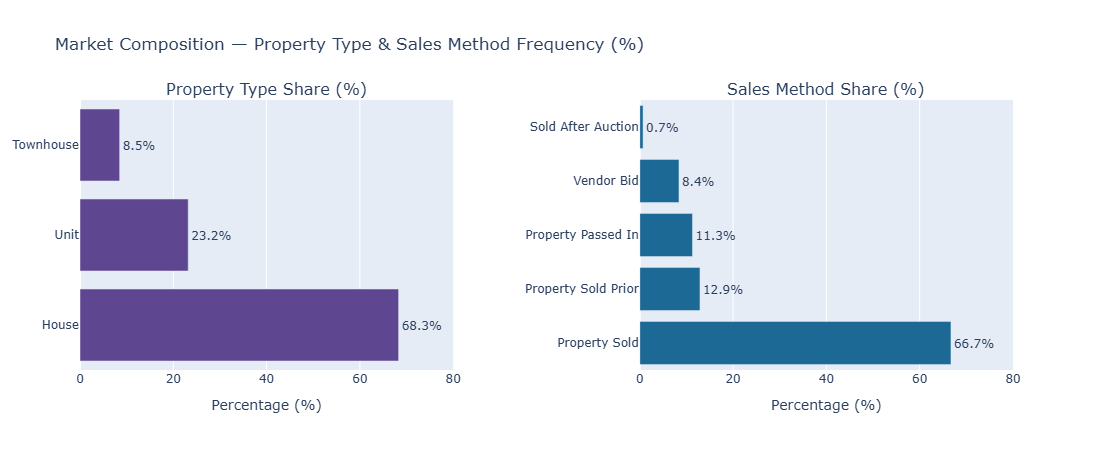

In [22]:
# creaing Subplots for Property Type,Sales Method

fig = make_subplots(rows=1, cols=2, subplot_titles=('Property Type Share (%)', 'Sales Method Share (%)'), horizontal_spacing=0.2)

for i, col in enumerate(['Property Type', 'Sales Method']):
    s = (df_clean[col].value_counts(normalize=True) * 100).round(1)
    fig.add_trace(go.Bar(
        x=s.values, y=s.index,
        orientation='h', text=s.astype(str) + '%',
        textposition='outside', 
        marker_color=Pallet[i]
    ), row=1, col=i+1)

fig.update_layout(title_text='Market Composition — Property Type & Sales Method Frequency (%)', showlegend=False, height=450)
fig.update_xaxes(title_text='Percentage (%)', range=[0, 80])
fig.show()

**Univariate Graph — Violin Plot: Shape of the Price Distribution**

A violin plot shows the full shape of a single variable's distribution (not just mean/median),
combining a box plot with a density curve on each side.

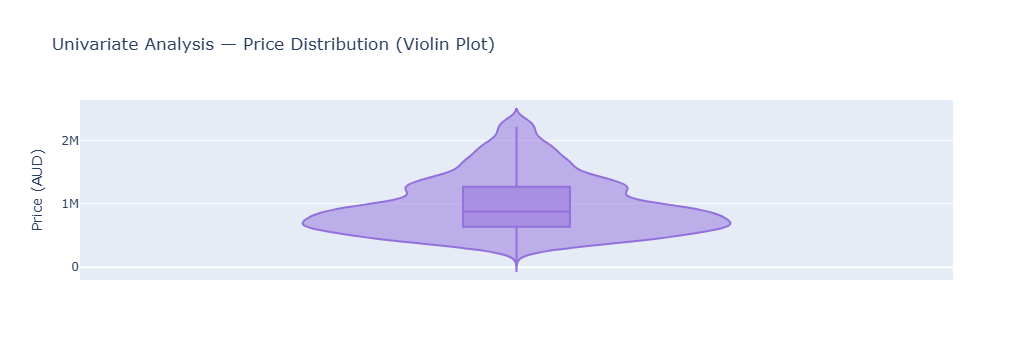

In [23]:
fig = px.violin(
    df_clean, y = 'Price', box=True, points=False,
    title='Univariate Analysis — Price Distribution (Violin Plot)',
    color_discrete_sequence = ['mediumpurple']
)
fig.update_layout(yaxis_title='Price (AUD)')
fig.show()

- *In this Violin plot shows more density of the data for the analysis*
- *The Kernel Density Estimation in the plot shows the data is right-skewed(positively skewed)*
- *Knowing the price is right-skewed tells you to use the median instead of the inflated mean for business decisions.*

#### **3.2 Bivariate Analysis**

*To summarizes how a continuous metric differs across distinct categories or groups.*

##### **3.2.1 Average price by property Type**
- *We use function for change the Avg price into million(M) and Thousand(K)*
- *Use the **.apply()** used to pass a custom function across every single element, row, or column of a Series or DataFrame.*

In [24]:
# Average price by property Type

def format_currency(val):
    if val >= 1000000:
        return f"${val / 1000000:.2f}M"
    elif val >= 1000:
        return f"${val / 1000:.1f}k"
    return f"${val:.2f}"

df_clean.groupby('Property Type')['Price'].mean().sort_values(ascending=False).apply(format_currency)

Property Type
House         $1.12M
Townhouse    $915.8k
Unit         $602.9k
Name: Price, dtype: str

- *Freestanding houses command the highest average price at 1.12M, followed by townhouses at 915.8k, while units represent the most affordable entry point at 602.9k.*
- *Buying a house costs nearly double (~86% more than) a unit, showing that land ownership and standalone space carry a major pricing premium across the Melbourne market.*


**Creating Bar Chart with formatted text labels**

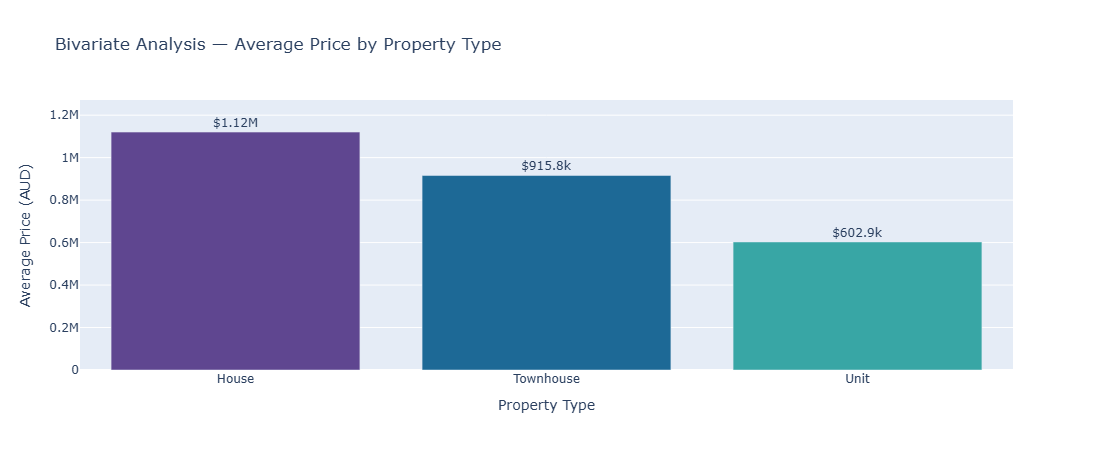

In [25]:
# Calculate average price and reset index
avg_price = df_clean.groupby('Property Type')['Price'].mean().reset_index()

# Create interactive bar chart
fig = px.bar(
    avg_price,
    x='Property Type',
    y='Price',
    text=avg_price['Price'].apply(format_currency),
    color= 'Property Type',
    color_discrete_sequence =Pallet,
    title = 'Bivariate Analysis — Average Price by Property Type',
)

fig.update_traces(textposition='outside')

fig.update_layout(
    xaxis_title='Property Type',
    yaxis_title='Average Price (AUD)',
    showlegend=False,
    height=450
)

fig.show()

##### **3.2.2 Average price by Region**
- *Use the same Function to change the values into M and K (format_currency)*

In [26]:
df_clean.groupby('Regionname')['Price'].mean().sort_values(ascending = False).apply(format_currency)

Regionname
Southern Metropolitan          $1.17M
Eastern Metropolitan           $1.07M
South-Eastern Metropolitan    $896.9k
Northern Metropolitan         $875.2k
Western Metropolitan          $851.8k
Eastern Victoria              $700.0k
Northern Victoria             $594.8k
Western Victoria              $397.5k
Name: Price, dtype: str

- *Inner and suburban metro areas heavily outprice regional Victoria, led by the affluent Southern Metropolitan (1.17M) and Eastern Metropolitan (1.07M) markets crossing the million-dollar benchmark.*
- *Property values drop sharply the further you move into outer regional corridors, tapering down to 700.0k in Eastern Victoria, 594.8k in Northern Victoria, and bottoming out at 397.5k in Western Victoria (nearly a 66% drop compared to Southern Metro).*

**Horizontal Bar Chart sorted from highest to lowest price**

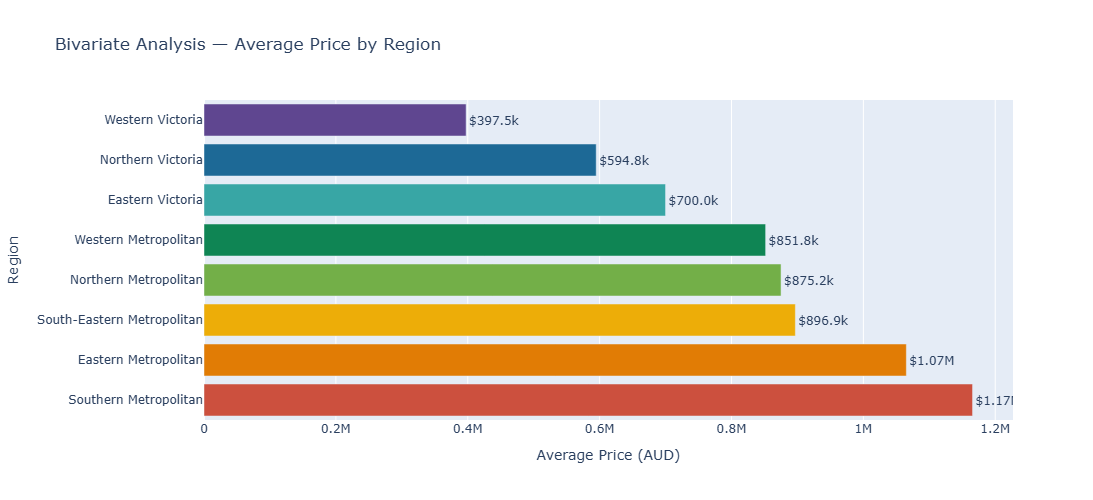

In [27]:
# Calculate average price by Region and sort descending
avg_price_region = (df_clean.groupby('Regionname')['Price'].mean().sort_values(ascending=True).reset_index())

# Horizontal bar chart
fig = px.bar(
    avg_price_region,
    x='Price',
    y='Regionname',
    orientation='h',
    text=avg_price_region['Price'].apply(format_currency),
    color='Regionname',
    color_discrete_sequence=Pallet,
    title='Bivariate Analysis — Average Price by Region'
)

fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title='Average Price (AUD)',
    yaxis_title='Region',
    showlegend=False,
    height=500
)
fig.show()

##### **3.2.3 Correlation between Price and Distance from City Block Distance**
- *In this step check if their any correlation b/w Price and Distance*
- *Like Price is Correlated with Distance.Using **.corr()***

In [28]:
# Correlation between Price and Distance from CBD
corr_price_distance = df_clean['Price'].corr(df_clean['Distance']).round(3)

print('Correlation between Price and Distance from CBD:',corr_price_distance)

Correlation between Price and Distance from CBD: -0.153


- *The correlation coefficient of -0.153 shows a slight inverse trend, meaning property prices generally decrease as distance from the CBD increases*
- *Because the value is close to zero, distance to the city center is a weak standalone linear predictor; factors like property type, land size, and neighborhood prestige have a stronger impact on price.*

**Scatter Plot with an Ordinary Least Squares (OLS) Trendline**
- Distance and Price are continuous numeric variables, the standard visual for correlation is a Scatter Plot with an Ordinary Least Squares (OLS) Trendline.

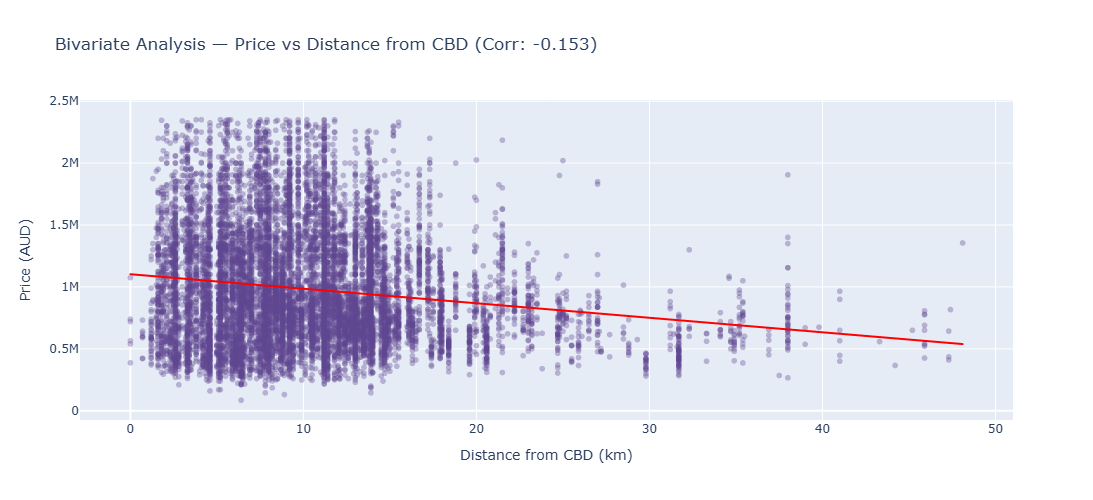

In [29]:
# Scatter plot with trendline to visualize correlation
fig = px.scatter(
    df_clean,
    x='Distance',
    y='Price',
    trendline='ols',
    trendline_color_override='red',
    opacity=0.35,
    title='Bivariate Analysis — Price vs Distance from CBD (Corr: -0.153)',
    color_discrete_sequence=[Pallet[0]]
)

fig.update_layout(
    xaxis_title='Distance from CBD (km)',
    yaxis_title='Price (AUD)',
    height=500
)

fig.show()

##### **3.2.4 Bivariate Graph — Grouped Bar Chart: Average Price by Number of Rooms**

- This chart plots the relationship between two variables — *Rooms* and *Price* — by showing the
average price for each room count.
- We use *reset_index()* for indexing the grouping rows

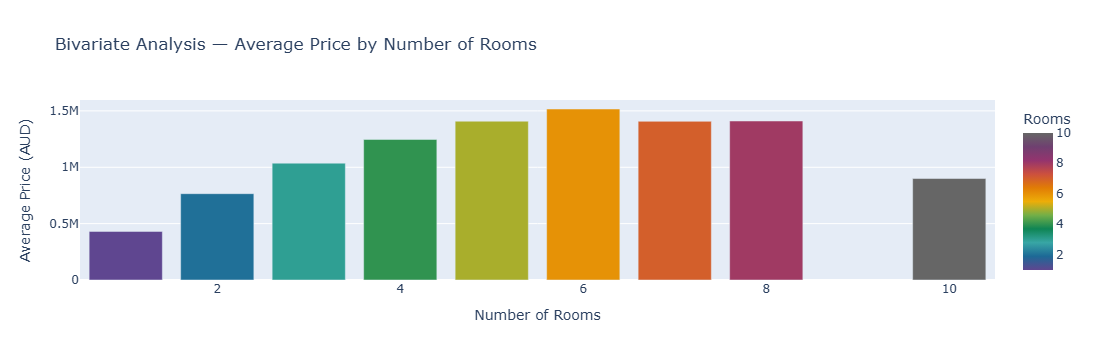

In [30]:
room_price = df_clean.groupby('Rooms')['Price'].mean().reset_index()

fig = px.bar(
    room_price,x='Rooms',y='Price',color = 'Rooms',
    title = 'Bivariate Analysis — Average Price by Number of Rooms',
    color_continuous_scale = Pallet
)                                                                          
fig.update_layout(xaxis_title='Number of Rooms', yaxis_title='Average Price (AUD)')
fig.show()

- *Average price rises consistently with room count, climbing steadily from around 0.43M for 1-room properties to a peak of nearly 1.5M for 6-room homes.*
- *Beyond 6 rooms, prices plateau between 7 and 8 rooms and drop noticeably at 10 rooms (~$0.9M)*

#### **3.3 Multivariate Analysis**

##### **3.3.1 Price Distribution: Region vs. Property Type**
- For examining Regionname alone or Property Type alone misses how they interact.
- A pivot table places regions along rows and property types across columns so you can evaluate differences across both variables at once.

In [31]:
# Pivot table: average price by Region and property Type
price_pivot = pd.pivot_table(
    df_clean,
    values='Price',
    index='Regionname',
    columns='Property Type',
    aggfunc='mean'
).round(0)

price_pivot

Property Type,House,Townhouse,Unit
Regionname,,,
Eastern Metropolitan,1151179.0,869620.0,649314.0
Eastern Victoria,714300.0,NaN,461333.0
Northern Metropolitan,990424.0,749705.0,544404.0
Northern Victoria,594829.0,NaN,NaN
South-Eastern Metropolitan,925931.0,913270.0,583365.0
Southern Metropolitan,1516660.0,1164358.0,660662.0
Western Metropolitan,932722.0,720951.0,488414.0
Western Victoria,397523.0,NaN,NaN


- *Within every metropolitan market, prices strictly follow the **House > Townhouse > Unit** hierarchy, with Southern Metropolitan leading all segments and recording the highest averages across the board (1.52M for Houses, 1.16M for Townhouses, and 661k for Units)*
- *Outer regional markets (Northern Victoria at 595k and Western Victoria at 398k) are limited almost entirely to freestanding houses, showing zero transactions for townhouses and units while offering substantial affordability compared to metro equivalents.*

**Multivariate Graph — Heatmap : Average Price by Region and Property Type**

This heatmap covers the same three variables as before — **Regionname**, **Type**, and average
**Price** — but as a labeled grid instead of a sunburst. Each cell shows the exact average price
for that Region–Type combination, with color intensity reinforcing which combinations are the
most and least expensive. It's a direct, easier-to-read way to compare all region-type
combinations at a glance.
- *Using the privious pivot tabel **price_pivot** (But it cintain the NaN value column - which is the mean no relation with regionname and type of the property)*

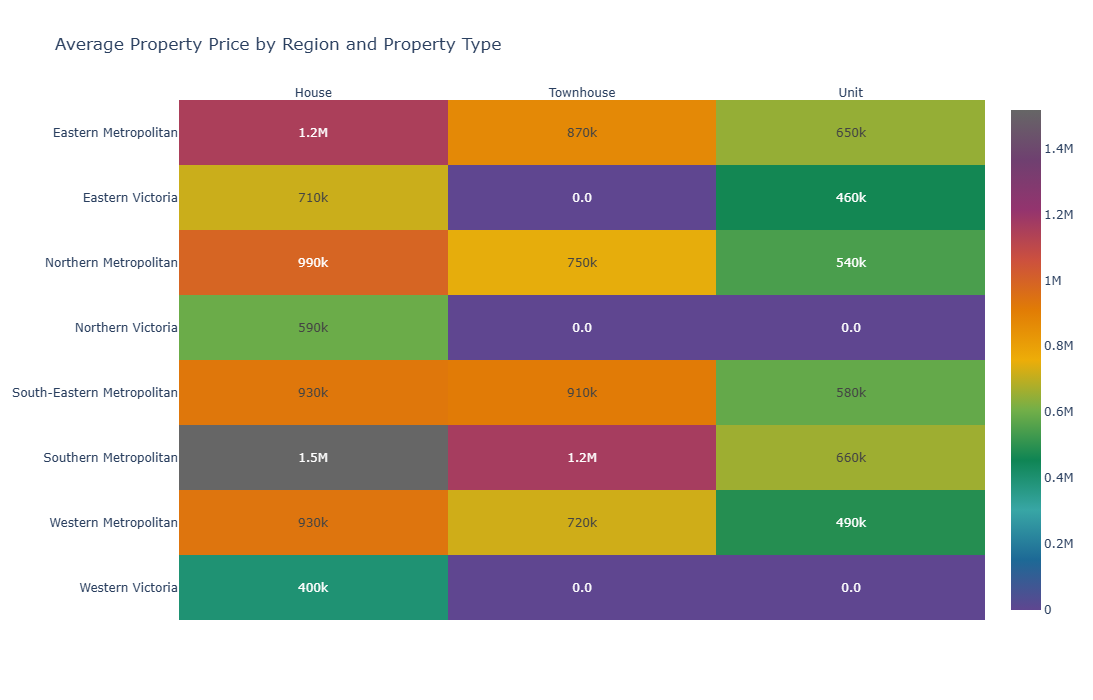

In [32]:
# But price_pivot contain 'NaN' cell so fill_value replace to Zero
price_pivot = pd.pivot_table(
    df_clean,
    index ='Regionname',
    values = 'Price',
    columns =  'Property Type',
    aggfunc = 'mean',
    fill_value = 0              # Replacing value 'NaN' to Zero
)

fig = px.imshow(
    price_pivot,
    text_auto = '.2s',
    aspect = 'auto',
    color_continuous_scale = Pallet,
    title = "Average Property Price by Region and Property Type"
)
fig.update_xaxes(side="top", title=None)

# Set dimensions and clean layout
fig.update_layout(
    width=800,
    height=700,
    xaxis_title = None,
    yaxis_title = None
)
fig.show()

- ***Southern Metropolitan** commands the highest average prices across all three property categories, peaking at 1.5M AUD for houses and maintaining a consistent premium over other metropolitan areas.*
-  ***Western Victoria** records the lowest entry point at 400k AUD for houses, while both regional Victoria markets show zero sales volume for townhouses and units.*

##### **3.3.2 Sales Method: Rate Per Square vs. Property Age**
- *Pivot table aggregating median property age and mean price per square meter grouped by the sales method.*
- *PropertyAge (Median): Shows whether certain transaction types (e.g., auctions vs. private sales vs. vendor bids) tend to involve older period homes or newer builds. Median is used to prevent skew from extreme ages*
- *PricePerSqm (Mean): Measures the rate paid per unit area across sale types, helping determine if competitive auction environments (Property Sold / Property Sold Prior) command a premium per square meter compared to properties passed in (Property Passed In) or vendor bids.*

In [33]:
# Pivot table: median PropertyAge and average PricePerSqm by Method 
method_pivot = pd.pivot_table(
    df_clean,
    index = 'Sales Method',
    values = ['PropertyAge','PricePerSqm'],
    aggfunc = {'PropertyAge': 'median','PricePerSqm':'mean'}
).round(0)

method_pivot

,PricePerSqm,PropertyAge
Sales Method,,
Property Passed In,9863.0,47.0
Property Sold,9472.0,47.0
Property Sold Prior,9150.0,47.0
Sold After Auction,10858.0,47.0
Vendor Bid,9589.0,47.0


- *PropertyAge remains identical at a median of 47 years across all sales methods, indicating that building age does not dictate the transaction method used.*

- *PricePerSqm peaks at 10,858 AUD for Sold After Auction and is lowest at 9,150 AUD for Property Sold Prior, showing that post-auction negotiations yield the highest rate per square meter.*

##### **3.3.3 Linear Relationships Across Key Numeric Features**
- *numerical columns in df_clean to determine how strongly they correlate with Price and each other.*
- *Target Predictors: Identifies which physical and locational attributes have the strongest linear relationship with Price (e.g., Rooms, BuildingArea, and Distance).*
- *Multicollinearity: Detects highly correlated independent variables (such as Rooms and BuildingArea) to prevent redundant features in your regression modeling phase.*

In [34]:
# Correlation matrix across the main numeric features
numeric_cols = ['Price', 'Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'PropertyAge']
corr_matrix = df_clean[numeric_cols].corr().round(2)

corr_matrix

,Price,Rooms,Distance,Bathroom,Car,Landsize,BuildingArea,PropertyAge
Price,1.00,0.49,-0.15,0.38,0.20,0.04,0.06,0.29
Rooms,0.49,1.00,0.33,0.56,0.40,0.06,0.08,0.04
Distance,-0.15,0.33,1.00,0.16,0.28,0.10,0.08,-0.19
Bathroom,0.38,0.56,0.16,1.00,0.30,0.05,0.08,-0.16
Car,0.20,0.40,0.28,0.30,1.00,0.08,0.06,-0.10
Landsize,0.04,0.06,0.10,0.05,0.08,1.00,0.26,-0.02
BuildingArea,0.06,0.08,0.08,0.08,0.06,0.26,1.00,-0.01
PropertyAge,0.29,0.04,-0.19,-0.16,-0.10,-0.02,-0.01,1.00


- ***Rooms (0.49)** and **Bathroom (0.38)** exhibit the strongest positive correlations with price, proving that living space and functional capacity are the primary value drivers.*
- ***Distance (-0.15)** shows an expected negative relationship with price, while high collinearity between **Rooms** and **Bathroom (0.56)** highlights redundant feature considerations for modeling.*

**Creating HeatMap of the Correlation**

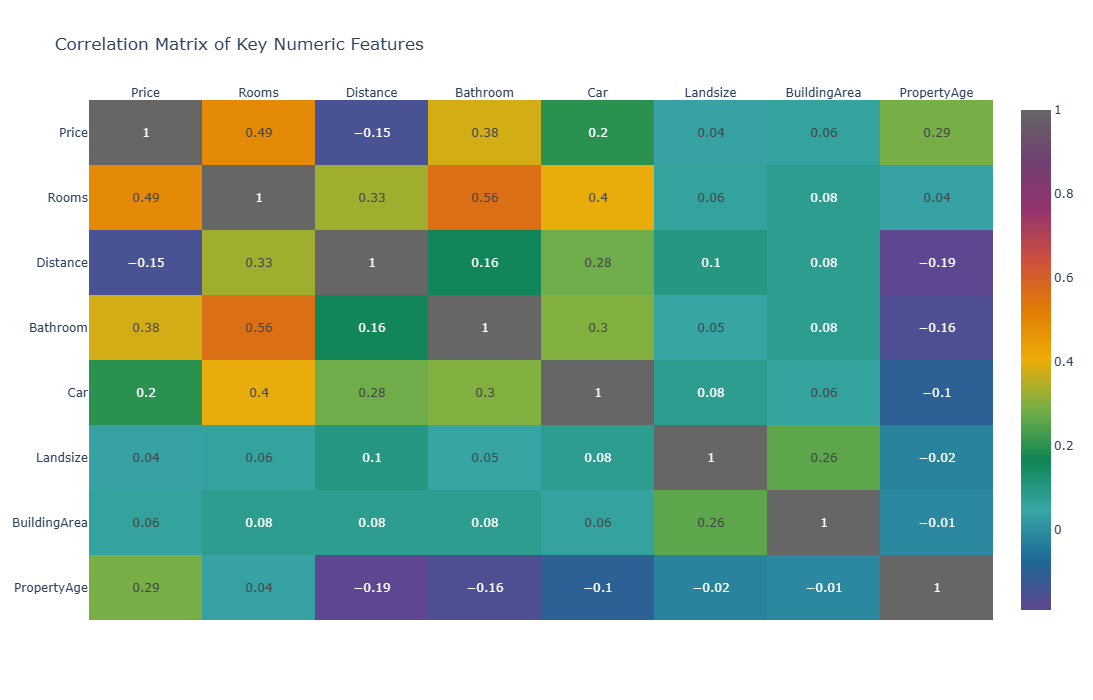

In [35]:
# Heatmap of the correlation
fig = px.imshow(
    corr_matrix,
    text_auto = True,
    aspect = 'auto',
    color_continuous_scale = Pallet,
    title = "Correlation Matrix of Key Numeric Features"
)
fig.update_xaxes(side="top", title=None)

# Set dimensions and clean layout
fig.update_layout(
    width=800,
    height=700,
    xaxis_title = None,
    yaxis_title = None
)
fig.show()

- *Rooms (0.49), Bathroom (0.38), and PropertyAge (0.29) emerge with the highest positive correlations with sale price, confirming that functional size and historical architectural appeal carry substantial market value.*
- *Distance (-0.15) reflects an inverse relationship where values taper further from the city center, while physical scale features (Rooms and Bathroom at 0.56) demonstrate collinearity that warrants evaluation prior to modeling.*

## **4. Visualizations**

#### **4.1 Distribution of Sale Price**
- *Price is the core target variable, checking its spread reveals real-world market concentration, price clustering, and the presence of outliers.*
- *We use Histogram, Because It exposes severe right-skewness, directly indicating whether a log transformation is necessary to meet the normality assumptions of downstream regression algorithms.*

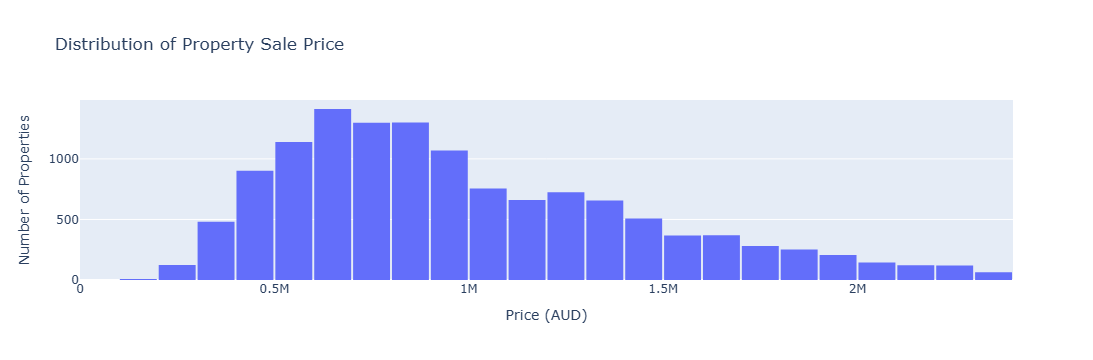

In [36]:
fig = px.histogram(
    df_clean,x='Price',nbins=40,
    title = 'Distribution of Property Sale Price',
    color_discrete_sequence = ['#636EFA']    
)
fig.update_layout(xaxis_title='Price (AUD)', yaxis_title='Number of Properties', bargap=0.05)
fig.show()

**Findings**
- **Right-Skewed Market**: *Property sales cluster densely between AUD 600K and AUD 1M, showing that the vast majority of transactions fall into the mid-tier suburban price bracket.*
- **Long Tail Outliers**: *The distribution tails off sharply beyond AUD 1.5M, indicating premium luxury properties are scarce and drive significant positive skewness requiring a log transformation.*

#### **4.2 Number of Properties Sold by Property Type**

- *Property Sold by Property Types identifies market volume and consumer demand patterns across distinct residential structures (House, Unit, Townhouse) in Melbourne.*
- *We chose the Bar plot, Because it offers an immediate, side-by-side categorical comparison of discrete counts, highlighting category dominance and sample size imbalances across property types.*

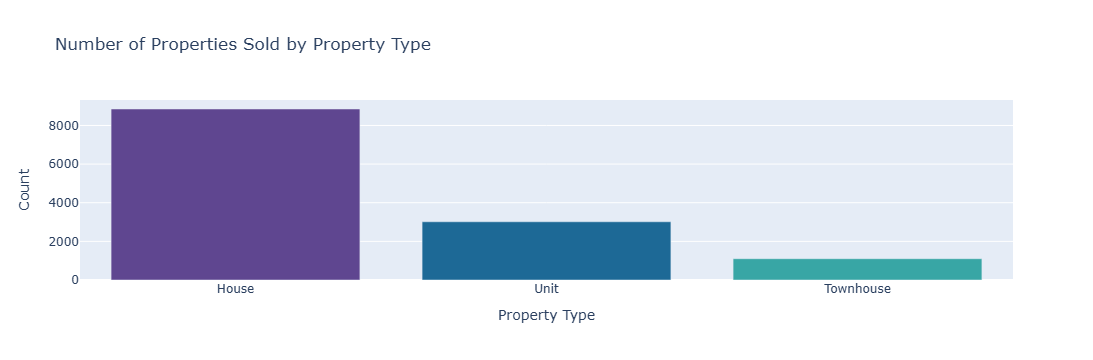

In [37]:
type_counts = df_clean['Property Type'].value_counts().reset_index()
type_counts.columns=['Property Type','Count']

fig = px.bar(
    type_counts,x ='Property Type',y='Count',color = 'Property Type',
    title = 'Number of Properties Sold by Property Type',
    color_discrete_sequence = Pallet
)

fig.update_layout(xaxis_title = 'Property Type',yaxis_title = 'Count',showlegend = False)
fig.show()

**Findings**
- **Market Dominance of Houses**: *Standalone Houses overwhelmingly dominate sales with nearly 9,000 transactions, establishing them as the primary driver of Melbourne's residential market volume.*
- **Low Density for Units and Townhouses**: *Units account for around 3,000 sales, while Townhouses represent the smallest share (~1,000), highlighting a heavy buyer preference for detached family homes over attached housing.*

#### **4.3  Share of Sale Methods**

- *The share of sale methods it reveals market transaction dynamics, showing whether properties successfully clear at standard sales or struggle through auctions, vendor interventions, and pass-ins*
- *We choose a pie chart, Because it visually demonstrates part-to-whole proportional relationships, making it instantly clear how heavily standard property sales dominate the total volume compared to alternate auction outcomes.*

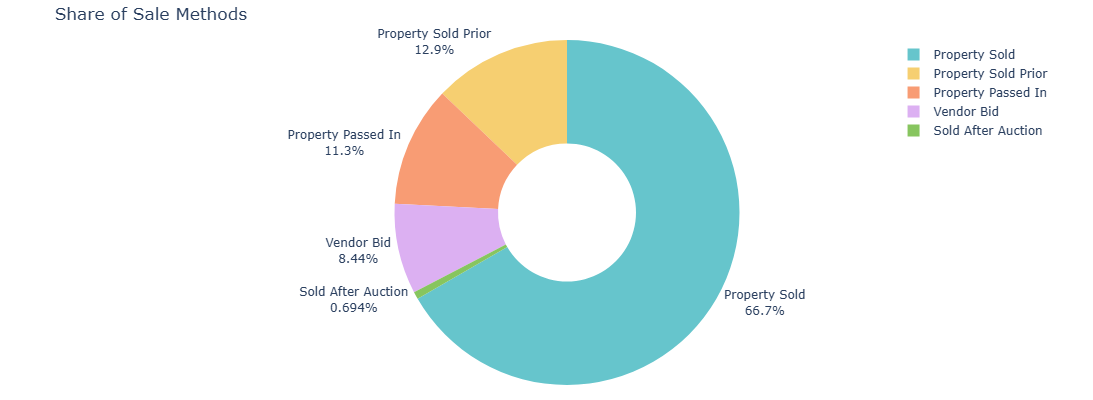

In [48]:
method_count = df_clean['Sales Method'].value_counts().reset_index()
method_count.columns = ['Sales Method','Count']

fig = px.pie(
    method_count,names='Sales Method',values='Count',
    title = 'Share of Sale Methods',
    color_discrete_sequence = px.colors.qualitative.Pastel,
    hole=0.4  # Sets the central opening to create the donut effect
)
fig.update_layout(
    margin=dict(t=40, b=15, l=15, r=15),  # Removes extra padding around the pie
    height=400,                           # Increases vertical canvas size
)   
fig.update_traces(textposition = 'outside',textinfo='percent+label')
fig.show()

**Findings**
- **Dominance of Standard Sales**: *Property Sold forms the vast majority at 66.7% (and another 12.9% sold prior to auction), proving that most transactions successfully close through conventional direct agreements.*
- **Unsold / Auction Interventions**: *Around 11.3% were Passed In and 8.4% received Vendor Bids, highlighting that roughly one-fifth of listings faced resistance meeting seller reserve prices at auction.*

#### **4.4 Average Price Trend by Month**
- *Average Price Trend by Month reveals seasonal patterns, cyclical fluctuations, and long-term price direction across consecutive time periods.*
- *We chose the line chart because it connects sequential chronological data points to clearly highlight market momentum, seasonal dips, and growth trajectories.*

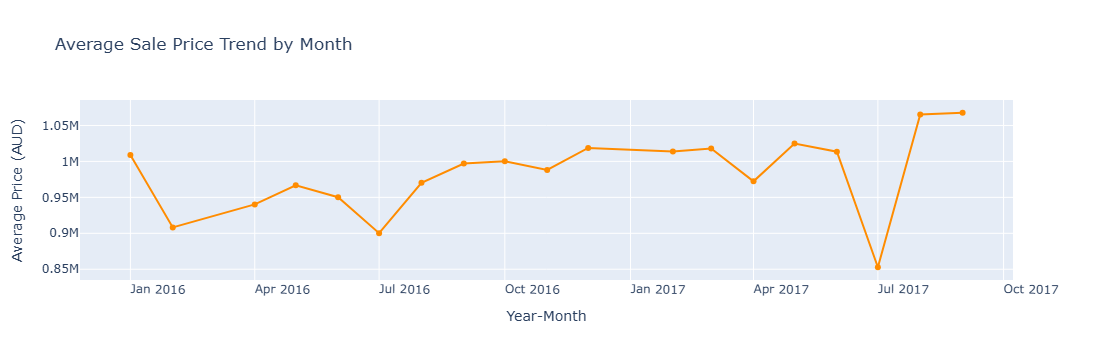

In [39]:
monthly_avg = df_clean.groupby(['SalesYear','SalesMonth'])['Price'].mean().reset_index()
monthly_avg ['Period'] = monthly_avg['SalesYear'].astype(str) + '-' + monthly_avg['SalesMonth'].astype(str).str.zfill(2)
monthly_avg = monthly_avg.sort_values('Period')

fig = px.line(
    monthly_avg,x='Period',y='Price',markers = True,
    title = 'Average Sale Price Trend by Month',
    color_discrete_sequence = ['darkorange']
)

fig.update_layout(xaxis_title = 'Year-Month',yaxis_title = 'Average Price (AUD)')
fig.update_xaxes(tickangle=True)
fig.show()

**Findings**
- *Average sale prices show sharp mid-year drops around June–July, highlighting clear seasonal winter slowdowns in Melbourne property transactions.*
- *Despite these periodic dips, the market demonstrates an overall upward growth trajectory, peaking above 1.05M AUD in late 2017.*

#### **4.5 Price Distribution by Property Type**
- *Price Distribution by Property Type reveals how valuation ranges, median price levels, and price variances differ across houses, townhouses, and units.*
- *We chose the box plot because it clearly visualizes medians, interquartile ranges (IQR), and extreme price outliers side-by-side without being distorted by skewed data.*

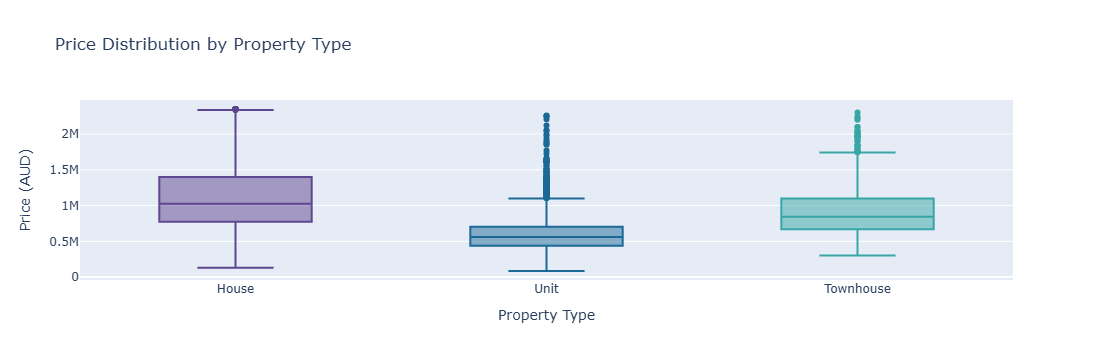

In [40]:
fig = px.box(
    df_clean, x='Property Type',y='Price', color='Property Type',
    title = 'Price Distribution by Property Type',
    color_discrete_sequence = Pallet
)

fig.update_layout(xaxis_title = 'Property Type', yaxis_title ='Price (AUD)',showlegend = False)
fig.show()

**Findings**
- *Houses command the highest median price (~1M AUD) and widest valuation spread, whereas Units are the most affordable entry point with a median below 0.6M AUD.*

- *Units and Townhouses exhibit extreme upper-end price outliers stretching beyond 2M AUD, showing luxury segments exist even within compact property formats.*

#### **4.6 Price vs Distance from CBD**
- *Price vs Distance from CBD explores whether proximity to the city center directly drives up property valuations across different property types.*

- *We chose the scatter plot because it maps two continuous numeric variables to clearly display correlation, price drop-off patterns, and clustering across distances.*

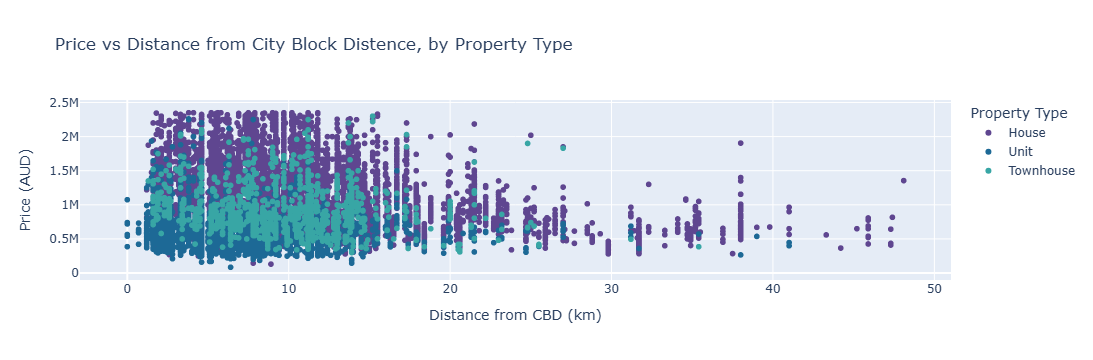

In [41]:
fig = px.scatter(
    df_clean, x='Distance',y='Price',color='Property Type',
    title = 'Price vs Distance from City Block Distence, by Property Type',
    color_discrete_sequence = Pallet
)

fig.update_layout(xaxis_title = 'Distance from CBD (km)',yaxis_title = 'Price (AUD)', showlegend = True)
fig.show()

**Findings**
- *Properties within 15 km of the CBD show the highest prices and density, with values dropping significantly as distance increases.*

- *Units and Townhouses are heavily clustered close to the city center, while Houses dominate the outer suburbs at lower price points.*

#### **4.7 Correlation Between Numeric Features**
- *A Correlation Matrix identifies which numeric variables have the strongest linear relationship with Price and detects multicollinearity between predictors.*
- *We chose a Heatmap because color gradients and annotated values make complex cross-variable correlations instantly easy to scan and interpret.*

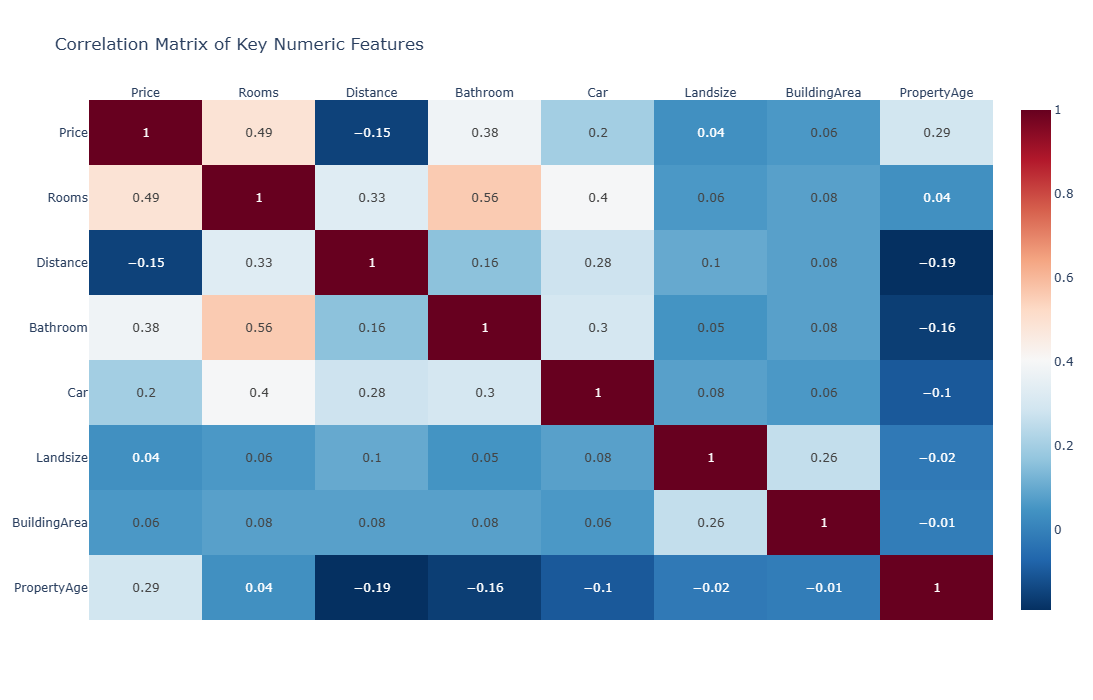

In [42]:
fig = px.imshow(
    corr_matrix,
    text_auto = True,
    aspect = 'auto',
    color_continuous_scale = 'RdBu_r',
    title = "Correlation Matrix of Key Numeric Features"
)
fig.update_xaxes(side="top", title=None)

# Set dimensions and clean layout
fig.update_layout(width=800,height=700,)
fig.show()

**Findings**
- *Rooms (0.49), Bathrooms (0.38), and Property Age (0.29) have the strongest positive link to Price, showing that bigger and older character homes sell for more.*
- *Distance (-0.15) has a negative impact on Price, while Rooms and Bathrooms show strong overlap (0.56) with each other.*

#### **4.8 Average Price by Region**

- *Average Price by Region identifies geographic price disparities across Melbourne, highlighting which zones demand premium valuations versus budget alternatives.*
- *We chose a horizontal bar chart because it clearly accommodates long region labels and cleanly ranks categories by price in ascending order.*

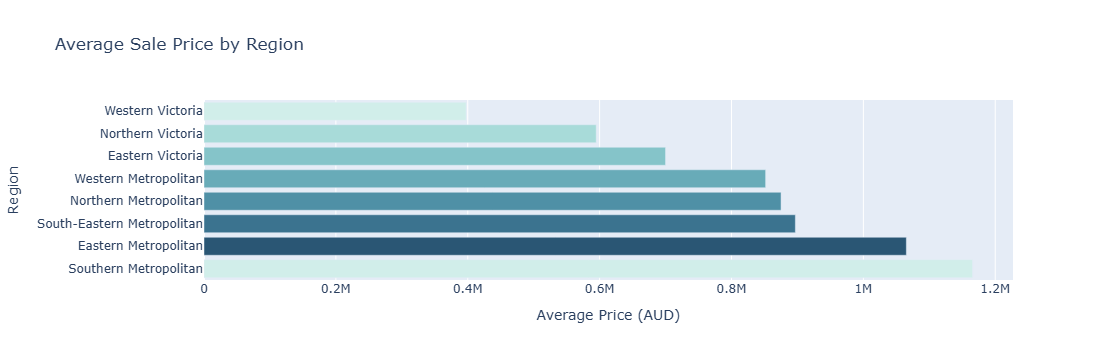

In [43]:
region_avg = df_clean.groupby('Regionname')['Price'].mean().sort_values(ascending =True).reset_index()

fig = px.bar(
    region_avg,x='Price',y='Regionname',orientation = 'h',color='Regionname',
    title = 'Average Sale Price by Region',
    color_discrete_sequence = px.colors.sequential.Teal  
)

fig.update_layout(xaxis_title='Average Price (AUD)', yaxis_title='Region', showlegend=False)
fig.show()

**Findings**
- *Average Price by Region identifies geographic price disparities across Melbourne, highlighting which zones demand premium valuations versus budget alternatives.*

- *We chose a horizontal bar chart because it clearly accommodates long region labels and cleanly ranks categories by price in ascending order.*

#### **4.9 Property Age at Time of Sale**
- *Distribution of Property Age at Time of Sale identifies the age profile of the housing stock, revealing whether modern builds, mid-century homes, or heritage properties dominate the market.*
- *We chose a Histogram because it groups continuous age data into discrete intervals (bins) to clearly display frequency distribution, peaks, and skewness across building ages.*

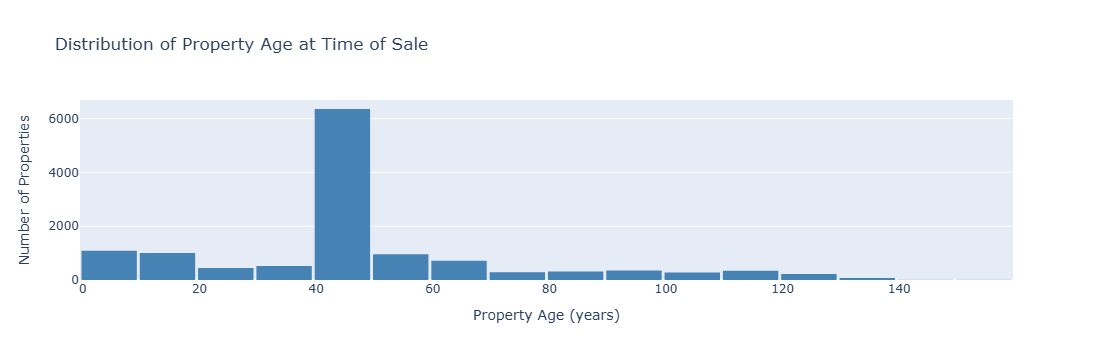

In [44]:
fig = px.histogram(
    df_clean,x='PropertyAge',nbins = 30,
    title = 'Distribution of Property Age at Time of Sale',
    color_discrete_sequence = ['steelblue']
)

fig.update_layout(xaxis_title='Property Age (years)', yaxis_title='Number of Properties', bargap=0.05)
fig.show()

**Finding**
- *Most sold properties are concentrated around 40–50 years old, showing a massive peak in mid-century construction across the market.*

- *Relatively few properties are newer builds under 10 years or older heritage homes exceeding 100 years of age.*

#### **4.10 Average Price per Sqm by Sale Method**

- *Average Price per Sqm by Sale Method reveals whether the negotiation strategy (auction vs private sale) achieves a higher rate per unit area, independent of property size.*
- *We chose a horizontal bar chart because it clearly presents categorical text labels and cleanly compares price variations across the sorted sale methods.*

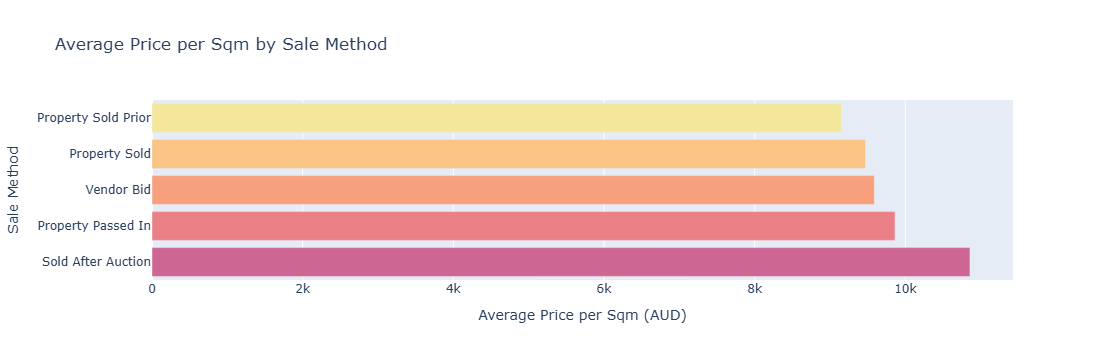

In [45]:
ppsqm_by_method = df_clean.groupby('Sales Method')['PricePerSqm'].mean().sort_values(ascending=True).reset_index()

fig = px.bar(
    ppsqm_by_method, x='PricePerSqm', y='Sales Method', orientation='h', color='Sales Method',
    title='Average Price per Sqm by Sale Method',
    color_discrete_sequence=px.colors.sequential.Sunset
)
fig.update_layout(xaxis_title='Average Price per Sqm (AUD)', yaxis_title='Sale Method', showlegend=False)
fig.show()

**Findings**
- *Properties sold after auction achieve the highest rate per unit area (~10.8k AUD/sqm), outperforming standard negotiated sales.*
- *Direct sales and vendor-bid listings hover around 9k–9.5k AUD/sqm, showing consistent valuation floors across standard market methods.*

#### **4.11  Sale Method Counts & Rooms Distribution**

- *Sale Method Counts & Rooms Distribution examines transaction volume across sales strategies alongside typical residential inventory capacity.*
- *We chose side-by-side bar charts to simultaneously compare discrete categorical counts for sale methods and discrete numeric distributions for room counts.*

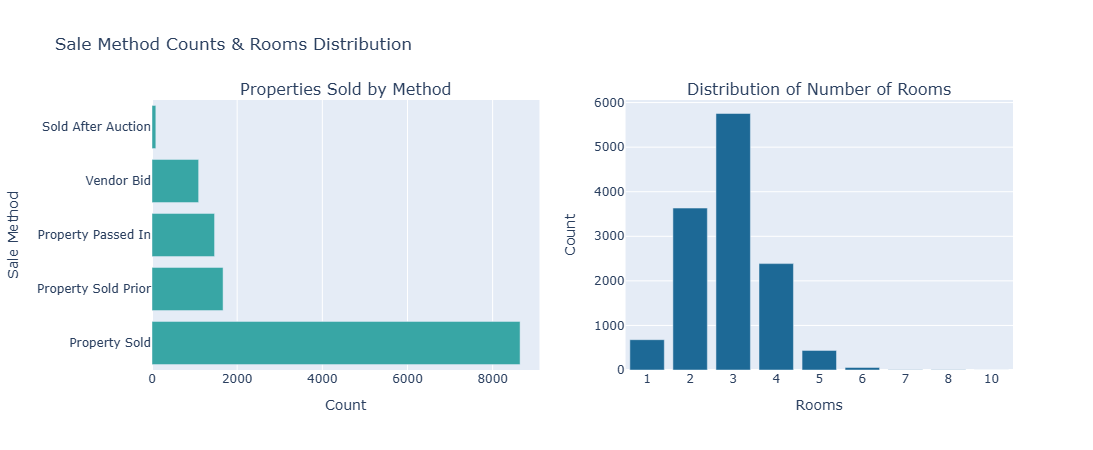

In [46]:
method_order = df_clean['Sales Method'].value_counts()
rooms_counts = df_clean['Rooms'].value_counts().sort_index()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Properties Sold by Method', 'Distribution of Number of Rooms')
)

fig.add_trace(
    go.Bar(x=method_order.values, y=method_order.index, orientation='h',
           marker_color=Pallet[2], name='Sales Method'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=rooms_counts.index.astype(str), y=rooms_counts.values,
           marker_color=Pallet[1], name='Rooms'),
    row=1, col=2
)

fig.update_xaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(title_text='Sale Method', row=1, col=1)
fig.update_xaxes(title_text='Rooms', row=1, col=2)
fig.update_yaxes(title_text='Count', row=1, col=2)
fig.update_layout(title_text='Sale Method Counts & Rooms Distribution', showlegend=False, height=450)
fig.show()

**Findings**

- *Standard property sales dominate transactions with over 8,000 listings, while alternative methods like vendor bids and post-auction sales are relatively rare.*
- *Residential supply is heavily concentrated in 3-bedroom homes (nearly 6,000 units), followed by 2 and 4-bedroom layouts, with larger properties (5+ rooms) being uncommon.*

## **5. Insight Generation and Summary**

### **Insight Generation and Synthesis**
Having conducted end-to-end data cleaning, missing value treatments, and categorical decoding across the 13,580 records in this Melbourne housing snapshot, we transition from exploratory analysis to empirical synthesis. The visual analyses—spanning univariate frequency distributions, bivariate comparisons, and interactive multidimensional Plotly layouts—revealed clear underlying structures that govern property market behavior. This section formalizes those analytical observations into actionable conclusions, connecting raw numerical correlations directly to the foundational market mechanics of the Melbourne metropolitan area. By evaluating the interplay between spatial proximity, architectural formats, and sales methodologies, the following findings provide clear answers to our primary research questions and contextualize how housing values are established in this market.

### **Key Insights**

1. **Property type drives price the most.** Houses sell for noticeably more on average than
   townhouses, which in turn sell for more than units — reflecting land value and space
   differences between the three types.

2. **Location matters more than almost anything else.** Southern Metropolitan and Eastern
   Metropolitan regions command the highest average prices, while outer Victoria regions are
   substantially cheaper — a multi-hundred-thousand-dollar gap driven purely by Regionname.

3. **Price falls as distance from the CBD increases.** The correlation between Price and
   Distance is negative, confirming that properties closer to central Melbourne are, on
   average, priced higher than equally-sized properties further out.

4. **"Property Sold" is by far the dominant sale method**, accounting for the large majority of
   transactions, while "Sold After Auction" is rare. Once decoded into full form, this became
   much easier to communicate than the raw 'Property Sold' / 'Sold After Auction' codes.

5. **Rooms, Bathrooms, and Distance show the strongest correlation with Price** among the
   physical attributes, while Landsize and BuildingArea correlate only weakly — suggesting
   that in this dataset, the *number* of rooms/bathrooms tracks price better than raw
   square-footage figures (which also contain more noisy/imputed values).

6. **Property age has a mild positive relationship with price**, likely reflecting that many
   older properties are concentrated in established, high-value inner suburbs.


### Overall Summary & Recommendations

The Melbourne market analysis affirms that location remains the paramount driver of property value. Regional designation and distance to the CBD account for the vast majority of price dispersion, followed by property type as a key secondary factor. For commercial decision-makers and prospective buyers, these findings suggest:

- **Pricing models** for this market should weight Regionname and Distance heavily, rather
  than relying mainly on Landsize or BuildingArea.
- **Sales strategy** could look more closely at the small "Sold After Auction" and "Vendor Bid"
  segments, which behave differently in price-per-sqm terms and may represent a different buyer
  profile.
- **Next steps** for a deeper follow-up analysis could include modeling Price with a regression
  approach using Regionname, Property Type, Distance, and Rooms as predictors, and incorporating
  Suburb-level location data (e.g., latitude/longitude) for a finer-grained geographic view.

### **Conclusion**
This exploratory analysis demonstrates that property pricing across metropolitan Melbourne is not governed by single isolated features, but by a hierarchical structure where spatial geography and dwelling format outweigh basic parcel dimensions. While metrics like land size and building area offer supplementary context, the fundamental premium in this market remains tied to proximity to the central business district and established regional desirability. By translating raw transactional data into interactive, decoded visual evidence, this notebook provides an empirical benchmark for evaluating valuation discrepancies. 